# (노트) CNN 기초내용

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [데이터과학]

In [3]:
import tensorflow as tf 
import tensorflow.experimental.numpy as tnp

In [24]:
import numpy as np

In [49]:
import matplotlib.pyplot as plt

In [50]:
tnp.experimental_enable_numpy_behavior()

### CONV의 역할

`-` 데이터생성 (그냥 흑백대비 데이터)

In [265]:
_X1 = tnp.ones([50,25])*10 
_X1

<tf.Tensor: shape=(50, 25), dtype=float64, numpy=
array([[10., 10., 10., ..., 10., 10., 10.],
       [10., 10., 10., ..., 10., 10., 10.],
       [10., 10., 10., ..., 10., 10., 10.],
       ...,
       [10., 10., 10., ..., 10., 10., 10.],
       [10., 10., 10., ..., 10., 10., 10.],
       [10., 10., 10., ..., 10., 10., 10.]])>

In [266]:
_X2 = tnp.zeros([50,25])*100 
_X2

<tf.Tensor: shape=(50, 25), dtype=float64, numpy=
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])>

In [267]:
tf.concat([_X1,_X2],axis=-1)

<tf.Tensor: shape=(50, 50), dtype=float64, numpy=
array([[10., 10., 10., ...,  0.,  0.,  0.],
       [10., 10., 10., ...,  0.,  0.,  0.],
       [10., 10., 10., ...,  0.,  0.,  0.],
       ...,
       [10., 10., 10., ...,  0.,  0.,  0.],
       [10., 10., 10., ...,  0.,  0.,  0.],
       [10., 10., 10., ...,  0.,  0.,  0.]])>

In [268]:
_noise = tnp.random.randn(50*50).reshape(50,50)
_noise

<tf.Tensor: shape=(50, 50), dtype=float64, numpy=
array([[-0.60577428,  1.26368868, -0.26268591, ..., -1.73978932,
         0.79099304, -0.64809419],
       [-0.91042958, -0.11826251, -1.09611045, ..., -1.0610891 ,
        -0.42939383,  0.56445234],
       [-0.66803579,  1.96442378, -0.12205009, ..., -0.80696837,
        -0.48960974, -2.26007362],
       ...,
       [ 2.34545698,  0.07593996,  1.13699361, ...,  0.52666174,
         2.12456243,  0.07767039],
       [ 0.31533871,  0.05552971,  2.38742666, ..., -0.09120232,
         0.28278018,  0.16317   ],
       [ 1.50073723,  0.6064122 ,  2.00830839, ..., -0.37481159,
        -1.8708704 ,  1.61505977]])>

In [269]:
XXX = tf.concat([_X1,_X2],axis=-1) + _noise
XXX

<tf.Tensor: shape=(50, 50), dtype=float64, numpy=
array([[ 9.39422572, 11.26368868,  9.73731409, ..., -1.73978932,
         0.79099304, -0.64809419],
       [ 9.08957042,  9.88173749,  8.90388955, ..., -1.0610891 ,
        -0.42939383,  0.56445234],
       [ 9.33196421, 11.96442378,  9.87794991, ..., -0.80696837,
        -0.48960974, -2.26007362],
       ...,
       [12.34545698, 10.07593996, 11.13699361, ...,  0.52666174,
         2.12456243,  0.07767039],
       [10.31533871, 10.05552971, 12.38742666, ..., -0.09120232,
         0.28278018,  0.16317   ],
       [11.50073723, 10.6064122 , 12.00830839, ..., -0.37481159,
        -1.8708704 ,  1.61505977]])>

In [270]:
XXX = XXX.reshape(1,50,50,1)

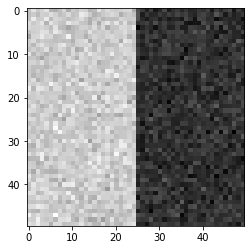

In [271]:
plt.imshow(XXX.reshape(50,50),cmap='gray')

`-` conv layer 생성

In [272]:
conv = tf.keras.layers.Conv2D(2,(2,2))

In [273]:
conv.weights # 처음에는 가중치가 없음

[]

In [274]:
conv(XXX) # 가중치를 만들기 위해서 하나 넣음

<tf.Tensor: shape=(1, 49, 49, 2), dtype=float32, numpy=
array([[[[-5.8774714e+00, -5.6950301e-01],
         [-5.8700008e+00,  8.5664585e-02],
         [-6.1222405e+00,  2.0969781e-01],
         ...,
         [ 9.7153336e-02,  7.0274425e-01],
         [ 4.5714977e-01, -1.0089302e+00],
         [-6.6963273e-01,  8.8716865e-01]],

        [[-6.2892199e+00,  1.6471101e+00],
         [-4.7146497e+00,  1.1139436e+00],
         [-5.2778254e+00,  2.2114331e-01],
         ...,
         [ 1.5498246e-02,  2.7203432e-01],
         [ 4.0995440e-01, -1.2756073e-01],
         [ 8.1334978e-01, -1.8448832e+00]],

        [[-5.1214113e+00, -1.1337665e+00],
         [-6.8209643e+00,  9.8493522e-01],
         [-6.0588512e+00,  1.3129706e+00],
         ...,
         [-1.8703446e-01,  9.0668631e-01],
         [ 1.1035691e+00, -4.2539972e-01],
         [ 2.5786909e-01,  1.1942625e+00]],

        ...,

        [[-4.3587632e+00,  1.3815138e+00],
         [-5.2792134e+00,  2.1731939e+00],
         [-4.6101785e+

In [275]:
conv.weights

[<tf.Variable 'conv2d_14/kernel:0' shape=(2, 2, 1, 2) dtype=float32, numpy=
 array([[[[-4.55753088e-01,  1.11984491e-01]],
 
         [[-1.15234375e-01, -6.90512180e-01]]],
 
 
        [[[ 3.86668503e-01,  6.05404377e-04]],
 
         [[-3.85833979e-01,  6.22431099e-01]]]], dtype=float32)>,
 <tf.Variable 'conv2d_14/bias:0' shape=(2,) dtype=float32, numpy=array([0., 0.], dtype=float32)>]

- 이제 가중치가 생겼다. 

`-` 필터값확인

In [276]:
conv.weights[0] # kernel에 해당하는것 

<tf.Variable 'conv2d_14/kernel:0' shape=(2, 2, 1, 2) dtype=float32, numpy=
array([[[[-4.55753088e-01,  1.11984491e-01]],

        [[-1.15234375e-01, -6.90512180e-01]]],


       [[[ 3.86668503e-01,  6.05404377e-04]],

        [[-3.85833979e-01,  6.22431099e-01]]]], dtype=float32)>

In [277]:
conv.weights[1] # bias에 해당하는것

<tf.Variable 'conv2d_14/bias:0' shape=(2,) dtype=float32, numpy=array([0., 0.], dtype=float32)>

`-` 필터값을 원하는 것으로 변경 

In [278]:
w0 = [[0.25,0.25],[0.25,0.25]] # 잡티를 제거하기 좋아보인다. 
w1 = [[-1.0,1.0],[-1.0,1.0]] # 경계점을 찾기 좋아보인다. 엣지검출

In [279]:
w = np.concatenate([np.array(w0).reshape(2,2,1,1), np.array(w1).reshape(2,2,1,1)],axis=-1)

In [280]:
b = np.array([0.0,0.0])

In [281]:
conv.set_weights([w,b])

In [282]:
conv.weights

[<tf.Variable 'conv2d_14/kernel:0' shape=(2, 2, 1, 2) dtype=float32, numpy=
 array([[[[ 0.25, -1.  ]],
 
         [[ 0.25,  1.  ]]],
 
 
        [[[ 0.25, -1.  ]],
 
         [[ 0.25,  1.  ]]]], dtype=float32)>,
 <tf.Variable 'conv2d_14/bias:0' shape=(2,) dtype=float32, numpy=array([0., 0.], dtype=float32)>]

- 첫번째는 평균필터, 두번째는 엣지검출필터

`-` 필터를 넣은 결과를 확인

In [283]:
conv(XXX)[...,0] # 채널0 

<tf.Tensor: shape=(1, 49, 49), dtype=float32, numpy=
array([[[ 9.907306  ,  9.946657  ,  9.814557  , ..., -0.2456145 ,
         -0.6098198 ,  0.06948934],
        [10.066924  , 10.157001  ,  9.743509  , ..., -0.5330368 ,
         -0.6967653 , -0.65365624],
        [10.529739  , 10.495738  , 10.4308405 , ..., -0.39270002,
         -0.42535675, -1.0828001 ],
        ...,
        [10.089812  ,  9.528799  ,  9.958275  , ...,  0.32771605,
          0.8729803 ,  0.5232537 ],
        [10.698067  , 10.913973  , 10.970761  , ...,  0.49626106,
          0.7107005 ,  0.6620458 ],
        [10.619504  , 11.264419  , 11.226563  , ..., -0.02603044,
         -0.513526  ,  0.04753488]]], dtype=float32)>

In [284]:
conv(XXX)[...,1] # 채널1

<tf.Tensor: shape=(1, 49, 49), dtype=float32, numpy=
array([[[ 2.6616306 , -2.5042229 ,  1.9758205 , ..., -4.619299  ,
          3.162478  , -0.44524103],
        [ 3.4246273 , -3.0643225 ,  1.4103575 , ..., -1.6039679 ,
          0.949054  , -0.77661777],
        [ 1.3336029 , -1.4696074 ,  1.2100143 , ...,  1.3113353 ,
         -1.4419622 , -1.1878113 ],
        ...,
        [-2.9953356 ,  0.7512808 ,  0.9666252 , ...,  1.9774555 ,
          0.20360136, -1.6025078 ],
        [-2.5293264 ,  3.39295   , -3.1657915 , ..., -1.1141253 ,
          1.9718833 , -2.1665022 ],
        [-1.1541348 ,  3.7337933 , -3.8852158 , ..., -0.8279062 ,
         -1.1220763 ,  3.36632   ]]], dtype=float32)>

`-` 각 채널을 시각화 

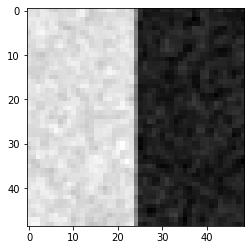

In [286]:
plt.imshow(conv(XXX)[...,0].reshape(49,49),cmap='gray') # 채널0 

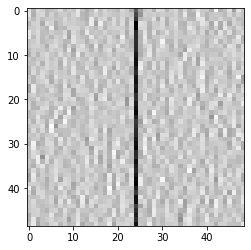

In [287]:
plt.imshow(conv(XXX)[...,1].reshape(49,49),cmap='gray') # 채널1

`-` 채널0을 XXX1, 채널1을 XXX1로 받자. 

In [288]:
XXX0=conv(XXX)[...,0]
XXX1=conv(XXX)[...,1] 

In [289]:
XXX0

<tf.Tensor: shape=(1, 49, 49), dtype=float32, numpy=
array([[[ 9.907306  ,  9.946657  ,  9.814557  , ..., -0.2456145 ,
         -0.6098198 ,  0.06948934],
        [10.066924  , 10.157001  ,  9.743509  , ..., -0.5330368 ,
         -0.6967653 , -0.65365624],
        [10.529739  , 10.495738  , 10.4308405 , ..., -0.39270002,
         -0.42535675, -1.0828001 ],
        ...,
        [10.089812  ,  9.528799  ,  9.958275  , ...,  0.32771605,
          0.8729803 ,  0.5232537 ],
        [10.698067  , 10.913973  , 10.970761  , ...,  0.49626106,
          0.7107005 ,  0.6620458 ],
        [10.619504  , 11.264419  , 11.226563  , ..., -0.02603044,
         -0.513526  ,  0.04753488]]], dtype=float32)>

In [290]:
XXX1

<tf.Tensor: shape=(1, 49, 49), dtype=float32, numpy=
array([[[ 2.6616306 , -2.5042229 ,  1.9758205 , ..., -4.619299  ,
          3.162478  , -0.44524103],
        [ 3.4246273 , -3.0643225 ,  1.4103575 , ..., -1.6039679 ,
          0.949054  , -0.77661777],
        [ 1.3336029 , -1.4696074 ,  1.2100143 , ...,  1.3113353 ,
         -1.4419622 , -1.1878113 ],
        ...,
        [-2.9953356 ,  0.7512808 ,  0.9666252 , ...,  1.9774555 ,
          0.20360136, -1.6025078 ],
        [-2.5293264 ,  3.39295   , -3.1657915 , ..., -1.1141253 ,
          1.9718833 , -2.1665022 ],
        [-1.1541348 ,  3.7337933 , -3.8852158 , ..., -0.8279062 ,
         -1.1220763 ,  3.36632   ]]], dtype=float32)>

`-` 이걸 다시 conv통과

In [292]:
conv(XXX0.reshape(1,49,49,1))

<tf.Tensor: shape=(1, 48, 48, 2), dtype=float32, numpy=
array([[[[ 1.0019472e+01,  1.2942791e-01],
         [ 9.9154320e+00, -5.4559135e-01],
         [ 1.0148041e+01,  1.4760323e+00],
         ...,
         [-2.6715016e-01, -4.8870200e-01],
         [-5.2130914e-01, -5.2793384e-01],
         [-4.7268802e-01,  7.2241831e-01]],

        [[ 1.0312350e+01,  5.6075096e-02],
         [ 1.0206772e+01, -4.7838879e-01],
         [ 1.0285830e+01,  7.9461956e-01],
         ...,
         [-4.6449751e-01,  6.5163970e-03],
         [-5.1196468e-01, -1.9638520e-01],
         [-7.1464461e-01, -6.1433434e-01]],

        [[ 1.0412856e+01, -3.0323410e-01],
         [ 1.0451929e+01,  4.5952702e-01],
         [ 1.0428719e+01, -5.5237103e-01],
         ...,
         [-2.7413577e-01, -5.3775018e-01],
         [-3.2418123e-01,  3.3756837e-01],
         [-4.9074727e-01, -1.0038326e+00]],

        ...,

        [[ 9.8780956e+00, -5.2090168e-01],
         [ 9.9868927e+00,  9.5609283e-01],
         [ 1.0270135e+

In [293]:
conv(XXX1.reshape(1,49,49,1))

<tf.Tensor: shape=(1, 48, 48, 2), dtype=float32, numpy=
array([[[[ 1.29428148e-01, -1.16548033e+01],
         [-5.45591831e-01,  8.95472336e+00],
         [ 1.47603178e+00, -8.68228912e-01],
         ...,
         [-4.88702029e-01, -1.04917250e+01],
         [-5.27933717e-01,  1.03347988e+01],
         [ 7.22418308e-01, -5.33339119e+00]],

        [[ 5.60750961e-02, -9.29216003e+00],
         [-4.78389502e-01,  7.15430164e+00],
         [ 7.94619799e-01, -2.06226444e+00],
         ...,
         [ 6.51636720e-03, -6.11330509e-01],
         [-1.96385205e-01, -2.00275660e-01],
         [-6.14334345e-01, -1.47152078e+00]],

        [[-3.03234339e-01, -3.05186272e-01],
         [ 4.59526062e-01,  3.35622787e+00],
         [-5.52369833e-01, -7.40381145e+00],
         ...,
         [-5.37750185e-01,  7.59582710e+00],
         [ 3.37568343e-01, -4.09455252e+00],
         [-1.00383258e+00, -1.27105117e+00]],

        ...,

        [[-5.20902395e-01,  5.06625652e+00],
         [ 9.56093550e-01, 

`-` 시각화

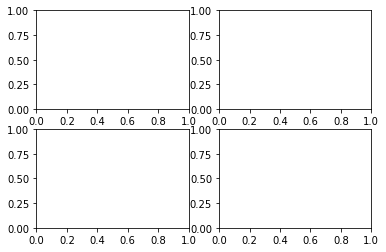

In [295]:
fig,((ax1,ax2),(ax3,ax4))=plt.subplots(2,2)

In [301]:
ax1.imshow(conv(XXX0.reshape(1,49,49,1))[...,0].reshape(48,48),cmap='gray')

In [302]:
ax2.imshow(conv(XXX0.reshape(1,49,49,1))[...,1].reshape(48,48),cmap='gray')

In [303]:
ax3.imshow(conv(XXX1.reshape(1,49,49,1))[...,0].reshape(48,48),cmap='gray')

In [304]:
ax4.imshow(conv(XXX1.reshape(1,49,49,1))[...,1].reshape(48,48),cmap='gray')

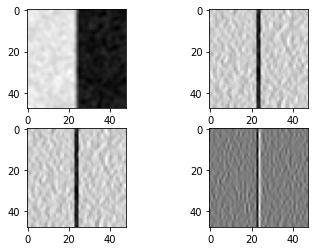

In [305]:
fig

- 스무딩2번, 스무딩1+엣지1, 엣지2번 

`-` 요약 

- 필터의 계수에 따라서 엣지를 검출하는 필터가 만들어지기도 하고, 스무딩을 하는 필터가 만들어지기도 한다. 
- 이들을 조합하면 다양한 조합이 가능하다. (엣지를 검출하고 스무딩을 한다든지) 이러한 조합으로 좀 더 좋은 특징추출기를 만들 수 있다. (엣지를 검출하는 필터도, 스무딩이후에 엣지를 잡아내면 더 효과가 좋다)
- 채널수를 많이 만들고 다양한 웨이트 조합을 가지면 이미지의 다양한 특징을 추출할 수 있을것이다? 

`-` 참고: 스트라이드, 패딩 

- 스트라이드: 윈도우가 1칸씩 이동하는 것이 아니라 2~3칸씩 이동함 (이미지 축소가 빠르게 이루어지는 효과)

- 패딩: 이미지의 가장자리에 적당한 값(예를들면 0)을 넣고 커널연산을 수행. 그래서 컨볼루션 연산 이후에도 이미지의 크기가 줄어들지 않도록 방지.

### MAXPOOL

`-` 왜 맥스풀링인가? (차원축소, 특징을 계층적으로 파악)

`-` 점점 작은 이미지가 되면서 중요한 특징들은 살아남지만 그렇지 않으면 죽는다. (캐리커쳐느낌)

`-` 평균이 아니라 max를 쓴 이유는? 평균보다 나을것 같아서..

`-` 최근에는 쓰지 않는 추세

### CNN 아키텍처의 표현방법 

`-` 아래와 같이 아키텍처형태로 주로 표현하고 굳이 이미지를 그리지는 않음 (출처: 위키피디아)

![](https://upload.wikimedia.org/wikipedia/commons/thumb/c/cc/Comparison_image_neural_networks.svg/2560px-Comparison_image_neural_networks.svg.png)

### discussion about CNN 

`-` 격자형태로 배열된 자료를 처리하는데 특화된 신경망이다. 
- 시계열 (1차원 격자), 이미지 (2차원 격자)

`-` 실제응용에서 엄청난 성공을 거두었다. 

`-` 이름의 유래는 컨볼루션이라는 수학적 연산을 사용하기 때문이다. 
- 컨볼루션은 조금 특별한 선형연산이다. 

`-` 신경과학의 원리가 심층학습에 영향을 미친 사례이다. 

#### 모티브 

`-` 희소성 + 매개변수공유 
- 다소 철학적인 모티브임 
- 희소성: 이미지를 분석하여 특징을 뽑아낼때 부분부분의 특징만 뽑으면 된다는 의미 
- 매개변수공유: 한채널에는 하나의 역할을 하는 커널을 설계하면 된다는 의미 (스무딩이든 엣징이든). 즉 어떤 지역은 스무딩, 어떤 지역은 엣징을 할 필요 없이 한채널에서는 스무딩, 한채널에서는 엣징을 하고 여러채널을 조합해서 이해하면 된다는 것  


`-` 당연한 소리같은데요, 파라메터 감소효과가 엄청납니다. 

(예시) (1,6,6,1) $\to$ (1,5,5,2) 

- MLP 방식이라면 $36\times 50$ 의 차원을 가진 매트릭스가 필요함  
- CNN 은 8개 

(예시) (1,224,224,3) $\to$ (1,224,224,16) 

#### 신경망의 구조

`-` 콘볼루션 - 활성화 - 풀링 

`-` 풀링: 요약의 의미 
- 요약은 굳이 왜하냐고? 아니 결국 요약은 해야한다. 어차피 결국 $y$ 는 0 or 1 이어야 하니까!
- 요약 하나도 안하고 있다가 나중에 한번에 하려면 힘들어요 

### 드랍아웃

`-` 아래의 예제를 복습하자. 

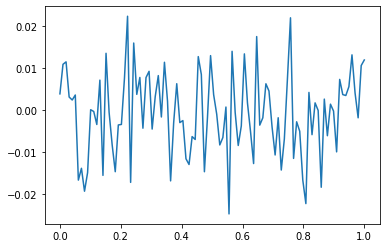

In [482]:
np.random.seed(43052)
N=100 
x = np.linspace(0,1,N).reshape(N,1) 
y = np.random.normal(loc=0,scale=0.01,size=(N,1))
plt.plot(x,y)

In [483]:
tf.random.set_seed(43052) 
net = tf.keras.Sequential()
net.add(tf.keras.layers.Dense(2048,activation='relu'))
net.add(tf.keras.layers.Dense(1))
net.compile(loss='mse',optimizer=tf.optimizers.Adam())
net.fit(x,y,epochs=5000,verbose=0,batch_size=N)

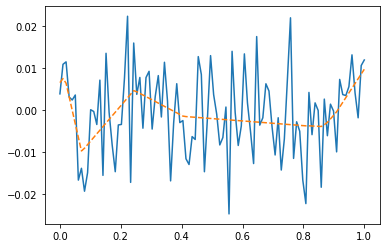

In [484]:
plt.plot(x,y)
plt.plot(x,net(x),'--')

`-` train/test 로 나누어서 생각해보자. 

In [485]:
tf.random.set_seed(43052) 
net = tf.keras.Sequential()
net.add(tf.keras.layers.Dense(2048,activation='relu'))
net.add(tf.keras.layers.Dense(1))
net.compile(loss='mse',optimizer=tf.optimizers.Adam())
net.fit(x[:80],y[:80],epochs=5000,verbose=0,batch_size=N)

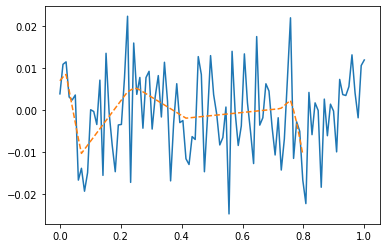

In [486]:
plt.plot(x,y)
plt.plot(x[:80],net(x)[:80],'--')
#plt.plot(x[80:],net(x)[80:],'--')

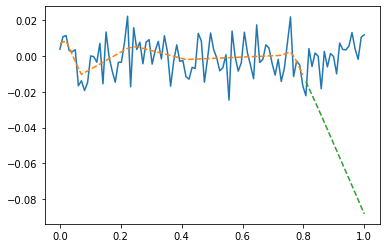

In [487]:
plt.plot(x,y)
plt.plot(x[:80],net(x)[:80],'--')
plt.plot(x[80:],net(x)[80:],'--')

- 추세를 따라가는게 좋은게 아니다. -> 그냥 직선으로 핏하는거 이외에는 다 오버핏임

`-` 적당히 빼고 학습하자? 

In [491]:
tf.random.set_seed(43052) 
net = tf.keras.Sequential()
net.add(tf.keras.layers.Dense(2048,activation='relu'))
net.add(tf.keras.layers.Dropout(0.8))
net.add(tf.keras.layers.Dense(1))
net.compile(loss='mse',optimizer=tf.optimizers.Adam())
net.fit(x[:80],y[:80],epochs=5000,verbose=0,batch_size=N)

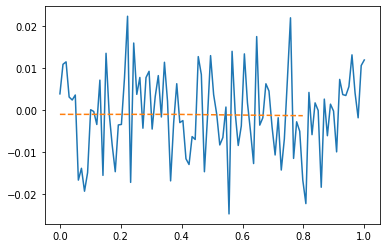

In [492]:
plt.plot(x,y)
plt.plot(x[:80],net(x)[:80],'--')
#plt.plot(x[80:],net(x)[80:],'--')

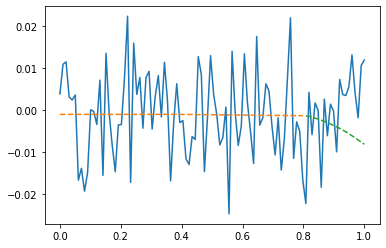

In [493]:
plt.plot(x,y)
plt.plot(x[:80],net(x)[:80],'--')
plt.plot(x[80:],net(x)[80:],'--')